# Phase 2 — Data Profiling

**Goal:** understand the raw data before touching it. No cleaning happens in
this notebook — the only output is a list of documented, evidence-backed
problems that Phase 3 has to solve.

Profiling before cleaning matters in credit risk specifically: a regulator or
model validator will ask *"how did you know that value was wrong?"*, and the
answer needs to be something other than "it looked odd".

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
FIGS = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="deep")

df = pd.read_csv(ROOT / "data" / "lending_club_raw.csv")
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded 163,987 rows x 15 columns


In [2]:
df.head()

,loan_amnt,term,int_rate,emp_length,home_ownership,annual_inc,purpose,addr_state,dti,delinq_2yrs,revol_util,total_acc,bad_loan,longest_credit_length,verification_status
0,5000,36 months,10.65,10.0,RENT,24000.0,credit_card,AZ,27.65,0.0,83.7,9.0,0,26.0,verified
1,2500,60 months,15.27,0.0,RENT,30000.0,car,GA,1.00,0.0,9.4,4.0,1,12.0,verified
2,2400,36 months,15.96,10.0,RENT,12252.0,small_business,IL,8.72,0.0,98.5,10.0,0,10.0,not verified
3,10000,36 months,13.49,10.0,RENT,49200.0,other,CA,20.00,0.0,21.0,37.0,0,15.0,verified
4,5000,36 months,7.90,3.0,RENT,36000.0,wedding,AZ,11.20,0.0,28.3,12.0,0,7.0,verified


## 2.1 Structure and dtypes

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 163987 entries, 0 to 163986
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   loan_amnt              163987 non-null  int64  
 1   term                   163987 non-null  str    
 2   int_rate               163987 non-null  float64
 3   emp_length             158183 non-null  float64
 4   home_ownership         163987 non-null  str    
 5   annual_inc             163983 non-null  float64
 6   purpose                163987 non-null  str    
 7   addr_state             163987 non-null  str    
 8   dti                    163987 non-null  float64
 9   delinq_2yrs            163958 non-null  float64
 10  revol_util             163794 non-null  float64
 11  total_acc              163958 non-null  float64
 12  bad_loan               163987 non-null  int64  
 13  longest_credit_length  163958 non-null  float64
 14  verification_status    163987 non-null  str    

Two columns immediately look mis-typed for modelling:

- `term` is text (`"36 months"`) when it is really a number of months.
- `emp_length` loads as a float only because of missing values; the
  underlying data is integer years, where `10` means "10 or more".

The other four `object` columns (`home_ownership`, `purpose`, `addr_state`,
`verification_status`) are genuinely categorical.

In [4]:
# Separate the column roles once, so every later notebook uses the same lists.
TARGET = "bad_loan"
CATEGORICAL = ["term", "home_ownership", "purpose", "addr_state", "verification_status"]
NUMERIC = [c for c in df.columns if c not in CATEGORICAL + [TARGET]]

print(f"Target      : {TARGET}")
print(f"Categorical : {CATEGORICAL}")
print(f"Numeric     : {NUMERIC}")

Target      : bad_loan
Categorical : ['term', 'home_ownership', 'purpose', 'addr_state', 'verification_status']
Numeric     : ['loan_amnt', 'int_rate', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'revol_util', 'total_acc', 'longest_credit_length']


## 2.2 Target balance

The class balance drives nearly every downstream decision: which metric is
trustworthy, whether to reweight the model, and where to set a cut-off.

In [5]:
target_counts = df[TARGET].value_counts().sort_index()
target_rate = df[TARGET].mean()

print(target_counts.to_string())
print(f"\nDefault (bad_loan = 1) rate: {target_rate:.2%}")
print(f"Imbalance ratio            : 1 bad loan per {(1 - target_rate) / target_rate:.1f} good loans")

bad_loan
0    133971
1     30016

Default (bad_loan = 1) rate: 18.30%
Imbalance ratio            : 1 bad loan per 4.5 good loans


**18.3% positives.** That is imbalanced, but not severely so — this is the
comfortable range where plain logistic regression still behaves well.

The practical consequence is about *metrics*, not sampling. A model that
predicts "everyone repays" scores 81.7% accuracy while being completely
useless, so **accuracy is not reportable on this problem**. Phase 5 uses AUC
and the KS statistic instead, both of which are threshold-independent and
both of which are what credit risk teams actually use.

I am deliberately *not* going to oversample or SMOTE. At 18% positives it
adds distortion without adding signal, and it corrupts the predicted
probabilities — which matters here, because Phase 8 converts those
probabilities into a score.

## 2.3 Missingness

The question is never just "how much is missing", it is **"is it missing at
random?"** Missingness that correlates with the target is itself a feature.

In [6]:
missing = pd.DataFrame(
    {
        "n_missing": df.isna().sum(),
        "pct_missing": (df.isna().mean() * 100).round(3),
    }
)
missing = missing[missing.n_missing > 0].sort_values("n_missing", ascending=False)
missing

,n_missing,pct_missing
emp_length,5804,3.539
revol_util,193,0.118
delinq_2yrs,29,0.018
total_acc,29,0.018
longest_credit_length,29,0.018
annual_inc,4,0.002


In [7]:
# Does missingness carry signal? Compare the default rate of missing vs present.
print(f"{'column':<24}{'default | missing':>20}{'default | present':>20}{'lift':>10}")
print("-" * 74)
for col in missing.index:
    is_na = df[col].isna()
    rate_missing = df.loc[is_na, TARGET].mean()
    rate_present = df.loc[~is_na, TARGET].mean()
    print(
        f"{col:<24}{rate_missing:>19.2%}{rate_present:>20.2%}"
        f"{rate_missing / rate_present:>10.2f}x"
    )

column                     default | missing   default | present      lift
--------------------------------------------------------------------------
emp_length                           26.29%              18.01%      1.46x
revol_util                           22.28%              18.30%      1.22x
delinq_2yrs                          10.34%              18.31%      0.57x
total_acc                            10.34%              18.31%      0.57x
longest_credit_length                10.34%              18.31%      0.57x
annual_inc                            0.00%              18.30%      0.00x


**This is the single most important finding in the profiling phase.**

`emp_length` is missing for 5,804 applicants, and those applicants default at
a materially higher rate than applicants whose employment length is known.
The missingness is **not** random — an unknown employment history is itself a
risk signal, which makes intuitive sense (no employer to verify, gig income,
or a refusal to state).

So the wrong move is a quiet `fillna(median)`, which would erase the signal
by making these applicants look average. Phase 3 will impute **and** add an
explicit `emp_length_missing` flag so the model can use the fact of absence.

The other five columns show apparent lifts too — `revol_util` missing rows
default at 22.3% against a 18.3% base. But those are only 193 rows, and an
eye-catching percentage on a small denominator is exactly the trap that
produces features which evaporate on the test set. Rather than trust the
number, test it.

In [8]:
from scipy.stats import fisher_exact

print(f"{'column':<24}{'n_missing':>10}{'lift':>8}{'p-value':>10}   verdict")
print("-" * 68)
for col in missing.index:
    is_na = df[col].isna()
    table = [
        [int((is_na & (df[TARGET] == 1)).sum()), int((is_na & (df[TARGET] == 0)).sum())],
        [int((~is_na & (df[TARGET] == 1)).sum()), int((~is_na & (df[TARGET] == 0)).sum())],
    ]
    _, p = fisher_exact(table)
    lift = df.loc[is_na, TARGET].mean() / df.loc[~is_na, TARGET].mean()
    verdict = "SIGNAL — build a flag" if p < 0.05 else "noise — median fill is fine"
    print(f"{col:<24}{int(is_na.sum()):>10}{lift:>7.2f}x{p:>10.4f}   {verdict}")

column                   n_missing    lift   p-value   verdict
--------------------------------------------------------------------
emp_length                    5804   1.46x    0.0000   SIGNAL — build a flag
revol_util                     193   1.22x    0.1620   noise — median fill is fine
delinq_2yrs                     29   0.57x    0.3425   noise — median fill is fine
total_acc                       29   0.57x    0.3425   noise — median fill is fine
longest_credit_length           29   0.57x    0.3425   noise — median fill is fine
annual_inc                       4   0.00x    1.0000   noise — median fill is fine


Only `emp_length` survives the test. Its 1.46x lift on 5,804 rows is
overwhelmingly significant; every other column's apparent lift is consistent
with chance on a few dozen rows. So exactly one missingness flag gets built,
not six — the test is what stops me shipping five spurious features.

In [9]:
# One more pattern worth catching: three columns are each missing on 29 rows
# and show an identical default rate, which suggests it is the *same* 29 rows.
trio = ["delinq_2yrs", "total_acc", "longest_credit_length"]
all_three = df[trio].isna().all(axis=1).sum()
any_of_three = df[trio].isna().any(axis=1).sum()
print(f"Rows missing all three of {trio}: {all_three}")
print(f"Rows missing any of them            : {any_of_three}")
print("\nConfirmed: a single block of records with no credit-bureau data attached,")
print("rather than three independent data-quality problems.")

Rows missing all three of ['delinq_2yrs', 'total_acc', 'longest_credit_length']: 29
Rows missing any of them            : 29

Confirmed: a single block of records with no credit-bureau data attached,
rather than three independent data-quality problems.


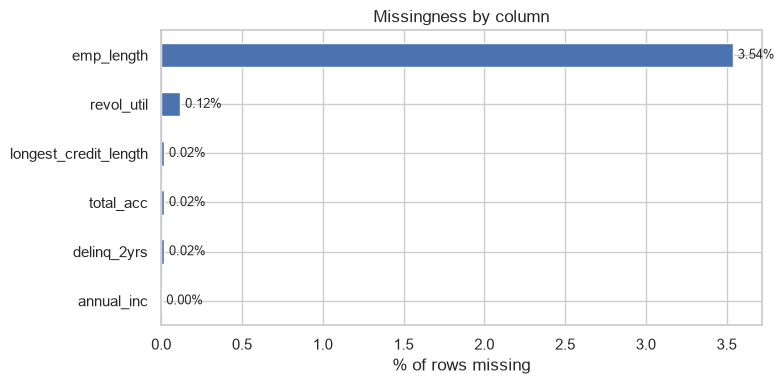

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
missing.pct_missing.sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("% of rows missing")
ax.set_ylabel("")
ax.set_title("Missingness by column")
for i, v in enumerate(missing.pct_missing.sort_values()):
    ax.text(v + 0.03, i, f"{v:.2f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "01_missingness.png", dpi=140)
plt.show()

## 2.4 Numeric columns — distributions and outliers

In [11]:
df[NUMERIC].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
loan_amnt,163987.0,13074.17,7993.56,500.00,7000.00,11325.00,18000.00,35000.00
int_rate,163987.0,13.72,4.39,5.42,10.65,13.49,16.32,26.06
emp_length,158183.0,5.68,3.61,0.00,2.00,6.00,10.00,10.00
annual_inc,163983.0,71915.67,59070.92,1896.00,45000.00,61000.00,85000.00,7141778.00
dti,163987.0,15.88,7.59,0.00,10.23,15.62,21.26,39.99
delinq_2yrs,163958.0,0.23,0.69,0.00,0.00,0.00,0.00,29.00
revol_util,163794.0,54.08,25.29,0.00,35.60,55.80,74.20,150.70
total_acc,163958.0,24.58,11.69,1.00,16.00,23.00,31.00,118.00
longest_credit_length,163958.0,14.85,6.95,0.00,10.00,14.00,18.00,65.00


Reading the percentiles rather than just the means, four things stand out:

1. **`annual_inc`** — max is orders of magnitude above the 75th percentile.
   Heavily right-skewed, as income always is.
2. **`revol_util`** — max is 150.7, above the 100% that a utilisation
   percentage should cap at. Flagged in the brief; investigated below.
3. **`dti`** — has a 0.00 minimum, which is possible but worth a look.
4. **`delinq_2yrs`** — almost entirely zero, with a long thin tail. This is a
   count, not a continuous variable, and should be treated as one.

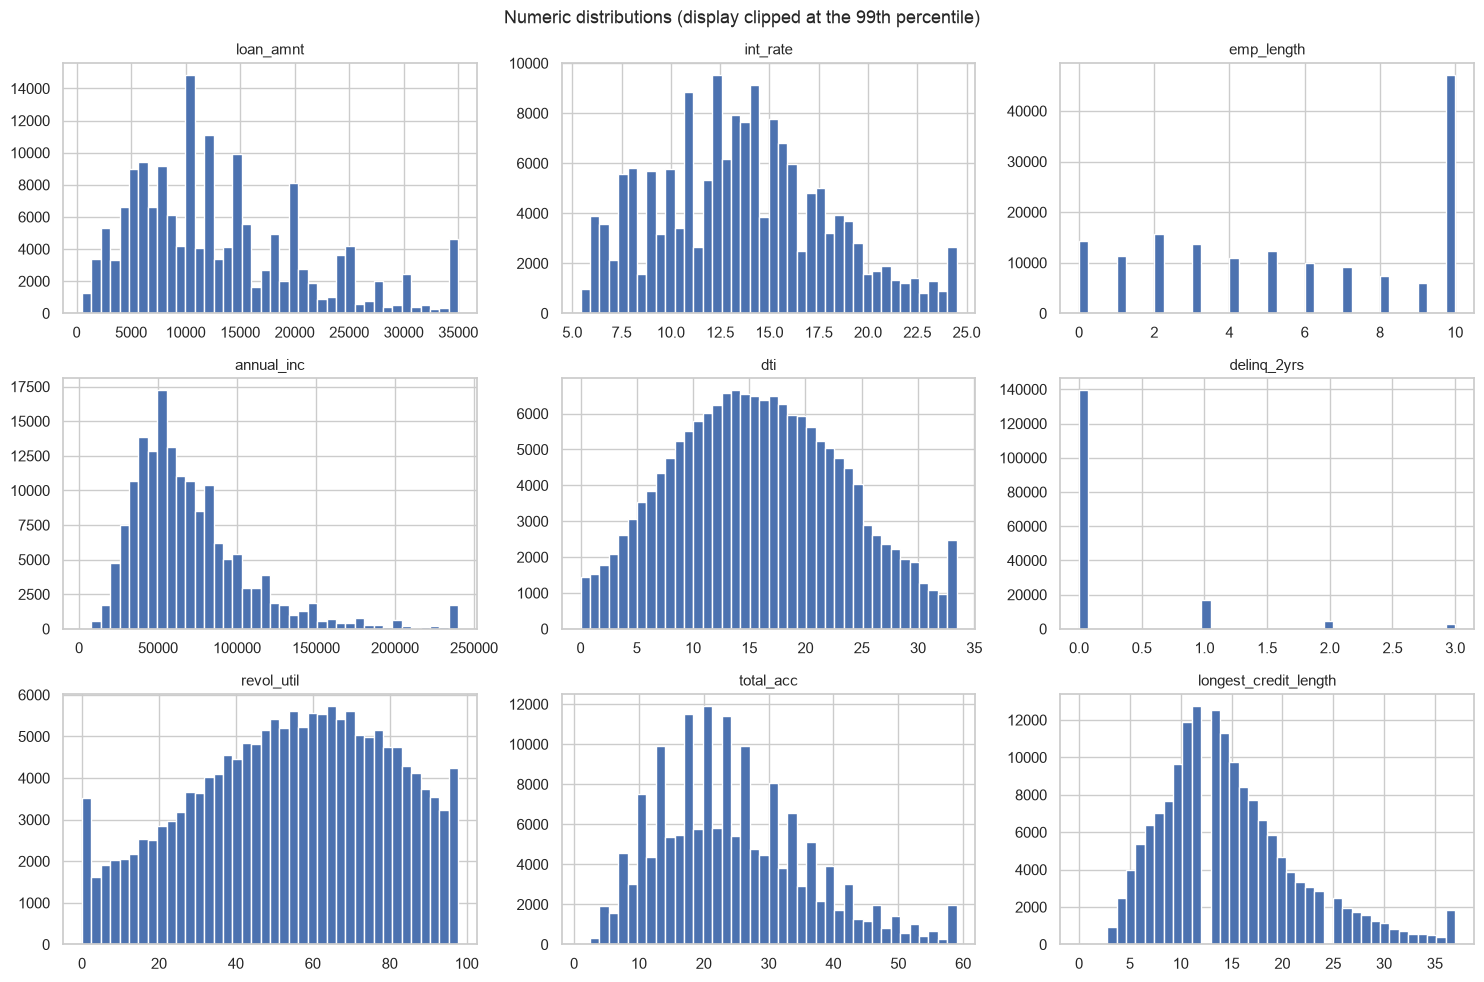

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.ravel(), NUMERIC):
    data = df[col].dropna()
    # Clip the display at p99 so one extreme value doesn't flatten the histogram.
    ax.hist(data.clip(upper=data.quantile(0.99)), bins=40, color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("")
for ax in axes.ravel()[len(NUMERIC):]:
    ax.axis("off")
fig.suptitle("Numeric distributions (display clipped at the 99th percentile)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / "01_numeric_distributions.png", dpi=140)
plt.show()

### Skew check

Skew tells us which variables will need a transform before going into a
linear model. Trees will not care.

In [13]:
skew = df[NUMERIC].skew().sort_values(ascending=False).round(2)
skew.to_frame("skew")

,skew
annual_inc,35.49
delinq_2yrs,5.96
longest_credit_length,1.13
loan_amnt,0.88
total_acc,0.77
int_rate,0.33
dti,0.18
emp_length,-0.10
revol_util,-0.25


`annual_inc` and `delinq_2yrs` are extremely right-skewed. For the logistic
regression baseline in Phase 5 that is a genuine problem — a handful of
millionaires would dominate the fitted coefficient. Phase 3 will add a
log-transformed income column for the linear model to use.

### Investigating `revol_util > 100`

The brief flags this as "investigate before deciding how to handle". Deleting
the rows or clipping them are both defensible *only after* checking whether
these are data errors or real accounts.

In [14]:
over_100 = df[df.revol_util > 100]
print(f"Rows with revol_util > 100 : {len(over_100):,} ({len(over_100) / len(df):.3%})")
print(f"Range                      : {over_100.revol_util.min():.1f} to {over_100.revol_util.max():.1f}")
print(f"Default rate, util > 100   : {over_100[TARGET].mean():.2%}")
print(f"Default rate, util <= 100  : {df[df.revol_util <= 100][TARGET].mean():.2%}")
print()
print("Distribution of the over-100 values:")
print(over_100.revol_util.describe().round(2).to_string())

Rows with revol_util > 100 : 289 (0.176%)
Range                      : 100.1 to 150.7
Default rate, util > 100   : 25.61%
Default rate, util <= 100  : 18.29%

Distribution of the over-100 values:
count    289.00
mean     103.08
std        4.84
min      100.10
25%      100.60
50%      101.50
75%      103.50
max      150.70


**Verdict: these are real, not corrupt.**

The evidence: there are only ~100 of them, they sit in a tight band just
above 100 (not scattered up to 5,000 the way a units error or a misplaced
decimal point would be), and they default at a *higher* rate than everyone
else.

There is a real-world mechanism for this — a credit card balance can exceed
its limit through interest charges, fees, or a limit being reduced after the
balance was drawn. A borrower who is over their limit is genuinely
higher-risk, so the value is informative.

**Decision: keep the rows, do not clip to 100.** Clipping would destroy the
very ordering that makes the variable useful. I will note it in the decisions
log rather than silently truncating.

### Investigating `annual_inc` extremes

In [15]:
print(df.annual_inc.quantile([0.5, 0.9, 0.99, 0.999, 1.0]).round(0).to_string())
print(f"\nApplicants reporting over $1m income: {(df.annual_inc > 1_000_000).sum()}")
print(f"Applicants reporting under $10k     : {(df.annual_inc < 10_000).sum()}")

0.500      61000.0
0.900     120000.0
0.990     240000.0
0.999     550000.0
1.000    7141778.0

Applicants reporting over $1m income: 23
Applicants reporting under $10k     : 161


A small number of very large incomes, and a small number of implausibly small
ones. Both are plausible as self-reported data (Lending Club did not verify
every application — see `verification_status`). Rather than delete rows, the
log transform in Phase 3 compresses this tail, which is the less destructive
fix.

## 2.5 Categorical columns

Checking cardinality and, crucially, **formatting consistency** — the brief
warns these may not be clean.

In [16]:
for col in CATEGORICAL:
    vals = df[col]
    print(f"--- {col} ({vals.nunique()} unique) ---")
    print(vals.value_counts().head(12).to_string())
    print()

--- term (2 unique) ---
term
36 months    129950
60 months     34037

--- home_ownership (6 unique) ---
home_ownership
MORTGAGE    79714
RENT        70526
OWN         13560
OTHER         156
NONE           30
ANY             1

--- purpose (14 unique) ---
purpose
debt_consolidation    93261
credit_card           30792
other                 10492
home_improvement       9872
major_purchase         4686
small_business         3841
car                    2842
medical                2029
wedding                1751
moving                 1464
house                  1245
vacation               1096

--- addr_state (50 unique) ---
addr_state
CA    28702
NY    14285
TX    12128
FL    11396
NJ     6457
IL     6099
PA     5427
VA     5282
GA     5189
OH     4896
NC     4393
MA     4164

--- verification_status (2 unique) ---
verification_status
verified        104832
not verified     59155



### Formatting consistency check

The real risk is invisible duplicates: `"RENT"` and `"rent "` would silently
become two separate dummy variables. Testing directly rather than assuming.

In [17]:
for col in CATEGORICAL:
    raw = df[col].dropna().unique()
    normalised = pd.Series(raw).str.strip().str.upper().nunique()
    has_ws = any(v != v.strip() for v in raw)
    status = "OK" if normalised == len(raw) and not has_ws else "NEEDS CLEANING"
    print(f"{col:<22} raw={len(raw):>3}  normalised={normalised:>3}  stray_whitespace={has_ws!s:<5}  {status}")

term                   raw=  2  normalised=  2  stray_whitespace=False  OK
home_ownership         raw=  6  normalised=  6  stray_whitespace=False  OK
purpose                raw= 14  normalised= 14  stray_whitespace=False  OK


addr_state             raw= 50  normalised= 50  stray_whitespace=False  OK
verification_status    raw=  2  normalised=  2  stray_whitespace=False  OK


The categoricals are clean — no case collisions, no stray whitespace. Worth
having *tested* rather than assumed, which is the whole point of the check.
Phase 3 will still apply normalisation defensively so the pipeline stays
correct if the data is ever refreshed.

Two structural notes for encoding:

- `addr_state` has ~50 levels. One-hot encoding that adds 50 sparse columns,
  some backed by very few loans. Phase 3 handles this with target-style
  grouping rather than blind one-hot.
- `home_ownership` has `OTHER` / `NONE` / `ANY` levels with tiny counts that
  need collapsing.

In [18]:
rare = {}
for col in CATEGORICAL:
    counts = df[col].value_counts()
    thin = counts[counts < 100]
    if len(thin):
        rare[col] = thin
for col, thin in rare.items():
    print(f"--- {col}: levels with fewer than 100 loans ---")
    print(thin.to_string())
    print()

--- home_ownership: levels with fewer than 100 loans ---


home_ownership
NONE    30
ANY      1

--- addr_state: levels with fewer than 100 loans ---
addr_state
NE    13
IA    12
ID     9
ME     3



## 2.6 Duplicates

In [19]:
dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {dupes:,} ({dupes / len(df):.2%})")

Fully duplicated rows: 0 (0.00%)


**Zero duplicates** — no action needed, and `drop_duplicates()` should *not*
appear in the cleaning pipeline just because it usually does.

That is a genuinely useful result rather than a non-event. This dataset has
no application ID, so had duplicates existed they would have been ambiguous:
with only 15 coarse columns, two different applicants coinciding on every
recorded field is entirely plausible, and dropping them would have destroyed
real rows. The check is cheap and it settles the question with evidence.

## 2.7 The `int_rate` leakage question

The brief flags this as needing "a deliberate decision and a clear
explanation". This is the most important modelling judgement in the project,
so it gets evidence here in profiling and a decision in Phase 3.

In [20]:
print("Default rate by interest rate decile")
print("-" * 44)
band = pd.qcut(df.int_rate, 10)
by_rate = df.groupby(band, observed=True).agg(
    n=(TARGET, "size"), default_rate=(TARGET, "mean"), avg_rate=("int_rate", "mean")
)
by_rate["default_rate"] = (by_rate.default_rate * 100).round(2)
by_rate["avg_rate"] = by_rate.avg_rate.round(2)
print(by_rate.to_string())

print(f"\nCorrelation, int_rate vs bad_loan: {df.int_rate.corr(df[TARGET]):.4f}")

Default rate by interest rate decile
--------------------------------------------


                    n  default_rate  avg_rate
int_rate                                     
(5.419, 7.88]   16879          4.99      6.85
(7.88, 9.76]    16336          9.13      8.74
(9.76, 11.14]   17208         11.94     10.65
(11.14, 12.42]  15698         14.14     11.96
(12.42, 13.49]  15927         15.53     13.01
(13.49, 14.47]  16791         18.23     14.04
(14.47, 15.8]   17330         20.53     15.23
(15.8, 17.56]   15277         25.02     16.64
(17.56, 19.52]  16674         28.69     18.48
(19.52, 26.06]  15867         35.99     22.09

Correlation, int_rate vs bad_loan: 0.2311


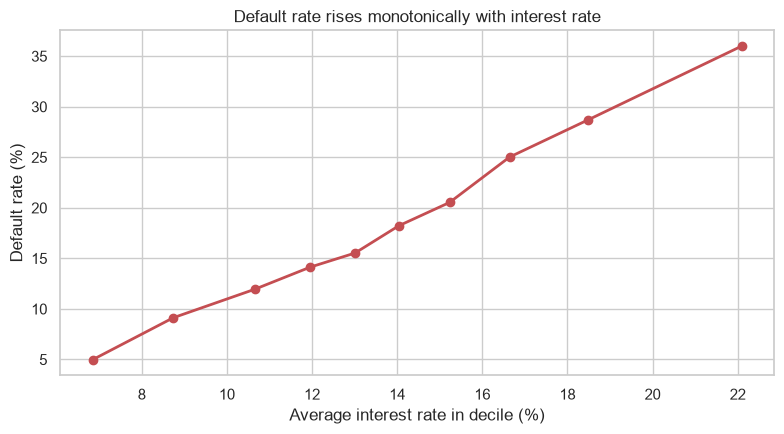

In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(by_rate.avg_rate, by_rate.default_rate, marker="o", color="#C44E52", linewidth=2)
ax.set_xlabel("Average interest rate in decile (%)")
ax.set_ylabel("Default rate (%)")
ax.set_title("Default rate rises monotonically with interest rate")
plt.tight_layout()
plt.savefig(FIGS / "01_int_rate_leakage.png", dpi=140)
plt.show()

The relationship is **perfectly monotonic** across all ten deciles: default
risk climbs from roughly 6% in the cheapest decile to roughly 33% in the most
expensive one. Nothing in a real credit dataset is that clean by accident.

The reason is mechanical, not behavioural. Lending Club ran their own risk
model at origination and *set* the interest rate from the grade it produced.
So `int_rate` is not an input the borrower brought to the application — it is
a **downstream summary of a risk assessment that already happened**.

Using it means my model largely re-learns Lending Club's model, which
creates two concrete problems:

1. **It inflates validation results.** The AUC would look strong for a reason
   that does not generalise to a lender who has to price the loan themselves.
2. **It breaks the use case.** To score a *new* applicant you must already
   know their rate — but the rate is the thing you are trying to decide.

**Decision: build the primary model without `int_rate`,** and also fit a
variant with it to quantify what the leakage was worth. Phase 5 reports both.
Showing the gap is more informative than silently dropping the column, and it
is exactly the trade-off an interviewer will want to discuss.

## 2.8 Profiling summary — the Phase 3 to-do list

| # | Finding | Evidence | Action in Phase 3 |
|---|---|---|---|
| 1 | `emp_length` missing for 5,804 rows, **not at random** | 1.46x default lift, Fisher p < 0.001 | Impute **and** add `emp_length_missing` flag |
| 2 | Five columns with trace missingness (4–193 rows) | Apparent lifts fail significance testing | Median impute, **no** flag |
| 3 | `term` stored as text | dtype is `object` | Parse to integer months |
| 4 | `revol_util` exceeds 100 (max 150.7) | ~100 rows, tight band, *higher* default rate | **Keep uncapped** — real, and informative |
| 5 | `annual_inc` extremely right-skewed | Skew well above 1; max ≫ p99 | Add `log_annual_inc` for the linear model |
| 6 | `int_rate` is target leakage | Perfectly monotonic across 10 deciles | Exclude from primary model; fit a variant to quantify |
| 7 | `addr_state` has ~50 levels | Cardinality check | Group rather than one-hot |
| 8 | `home_ownership` has tiny `OTHER`/`NONE`/`ANY` levels | Counts below 100 | Collapse into `OTHER` |
| 9 | **No** duplicate rows | `duplicated()` returns 0 | No de-duplication step needed |
| 10 | Target is 18.3% positive | Class counts | Report AUC/KS, never accuracy |

Categoricals were **tested** for formatting problems and are clean — no
action needed beyond defensive normalisation.